# AS-AD Model 

In [65]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%load_ext autoreload
%autoreload 2

from ASADmodel_true import ASAD_class

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The three main model equations:
$$y_t-\bar{y} = \frac{\beta_1}{1+\beta_1 \frac
{b}{\theta}+\beta_2 b}e^r_{t-1} - \frac{\hat{\beta}_1}{1+\beta_1 \frac
{b}{\theta}+\beta_2 b}(\pi_t-\pi^f)+\frac
{1}{1+\beta_1\frac{b}{\theta} +\beta_2 b}z_t$$

$$\pi_t = \pi^f +\gamma (y_t-\bar{y})+s_t$$
$$e^r_{t} = e^r_{t-1} - (1+\frac{h}{\theta}) (\pi_t-\pi^f) -\frac{b}{\theta} (y_t-\bar{y})$$

On gap-form such that, $y-\bar{y}=\hat{y}$, and using $\hat{\beta}_2=1+\beta_1 \frac
{b}{\theta}+\beta_2 b$, we get:
$$\hat{y}_t = \frac{\beta_1}{\hat{\beta}_2}e^r_{t-1} - \frac{\hat{\beta}_1}{\hat{\beta}_2}\hat{\pi}+\frac
{1}{\hat{\beta}_2}z_t \tag{AD}$$
$$\hat{\pi}_t = \gamma \hat{y}_t+s_t \tag{AS}$$
$$e^r_{t} = e^r_{t-1} - (1+\frac{h}{\theta}) \hat{\pi}_t -\frac{b}{\theta} \hat{y}_t$$

These three equations describes an open economy with floating exchange rates, where the Central Bank reacts to outputgaps and inflationtarget differences, through $h$ and $b$. 

Dermed fås de tre ligninger, som beskriver en åben økonomi med flydende valutakurser, hvor centralbanken både inflation- og outputtargetter.

Setting $h=b=0$ we get an economy running a fixed rate policy. 

Setting $b=0$, the model collapses to an AS-AD economy with floating exchange rates and strict inflation target policy, as seen in Macroeconomics II at KU. 

Hvis man satte $h=b=0$ ville økonomien føre fastkurs til udlandet.

Hvis man satte $b=0$ ville økonomien være flydende valutakurser med strict inflation targetting (Den normale makro 2 AS-AD åben økonomi med flydende valutakurser)

In [66]:
# Create model instance, set baseline parameters and allocate paths
model = ASAD_class()
par = model.par
path = model.path

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


## 1. Single shocks

We want to see how the economy adjusts from demand and supply shocks, respectively. Below we see how the economy adjust back to outputgap- and inflation-targets in the face of a 100 period constant demand shock. 

In [67]:
model.shocks(1,100,1,z=True)
model.solve()

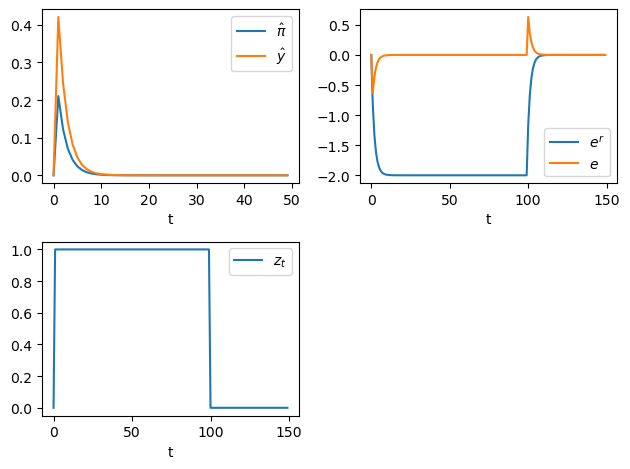

In [68]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,50,1),model.path.pihat[:50],label=r'$\hat{\pi}$')
ax.plot(range(0,50,1),model.path.yhat[:50],label=r'$\hat{y}$')
ax.legend(frameon=True)
ax.set_xlabel('t')
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,150,1),model.path.er[:150],label=r'$e^r$')
ax.plot(range(0,150,1),model.path.e[:150],label=r'$e$')
ax.legend(frameon=True)
ax.set_xlabel('t')
fig.tight_layout()

ax = fig.add_subplot(2,2,3)
ax.plot(range(0,150,1),model.path.z[:150],label=r'$z_t$')
ax.legend(frameon=True)
ax.set_xlabel('t')
fig.tight_layout()

In the period following the demand shock both the inflationtarget gap and output spike, but gradually adjusts towards zero in roughly 10 periods. The real exchange rate drops significantly, and does not adjust before the shock is gone, while the floating rate adjusts realtively quickly. 

In [69]:
model.shocks(1,100,1,s=True)
model.solve()

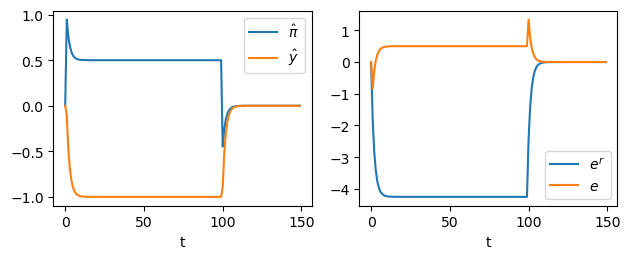

In [70]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,150,1),model.path.pihat[:150],label=r'$\hat{\pi}$')
ax.plot(range(0,150,1),model.path.yhat[:150],label=r'$\hat{y}$')
ax.legend(frameon=True)
ax.set_xlabel('t')
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,150,1),model.path.er[:150],label=r'$e^r$')
ax.plot(range(0,150,1),model.path.e[:150],label=r'$e$')
ax.legend(frameon=True)
ax.set_xlabel('t')
fig.tight_layout()

## 2. Stochastic Shocks

In [71]:
model.stochastic_shocks(0,1,z=True)
model.solve()

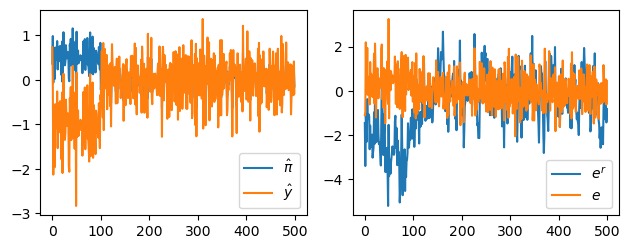

In [72]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

In [73]:
model.stochastic_shocks(0,1,s=True)
model.solve()

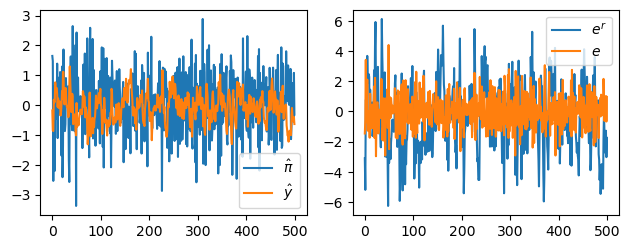

In [74]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

## 3. Persistent, stochastic shocks (AR)

### Demand shocks as an AR-process

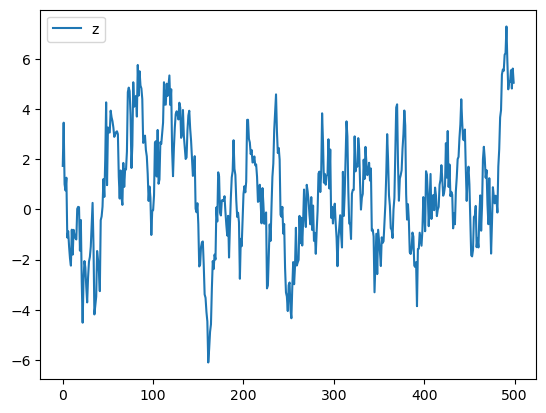

In [75]:
model.AR_shocks(rho=0.9,sd=1,z=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.z,label=r'z')
ax.legend(frameon=True)

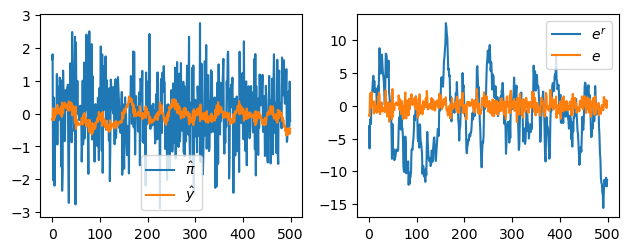

In [76]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

### Supply shocks as an AR-process

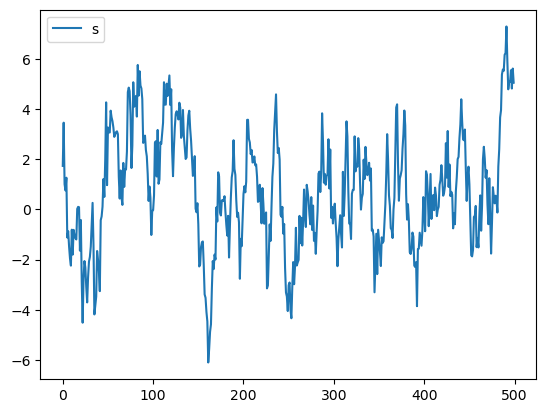

In [77]:
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.z,label=r's')
ax.legend(frameon=True)

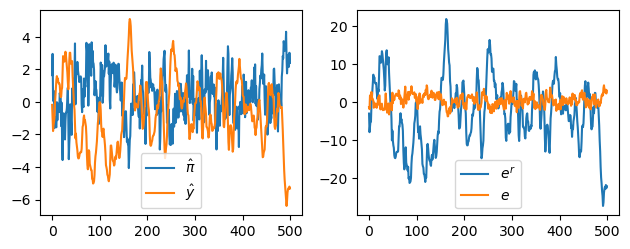

In [78]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

## 4. The super, social planner, living in an AR-world

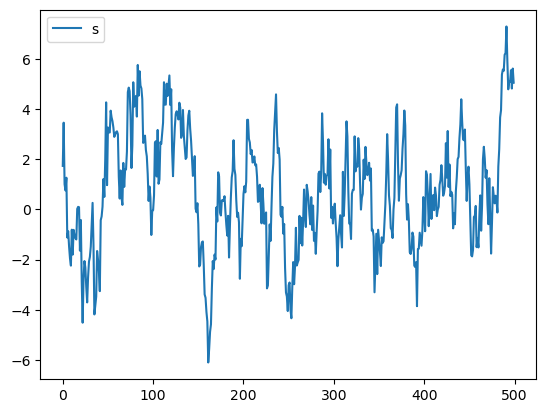

In [79]:
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.z,label=r's')
ax.legend(frameon=True)

In [80]:
sl = np.zeros((20,20))
possible_h = np.linspace(0,2,num=20)
possible_b = np.linspace(0,2,num=20)

def slhb(h,b):
    model.par.h = h
    model.par.b = b
    model.solve()
    return model.compute_social_loss()

In [81]:
sl_best = np.inf
h_best = np.nan
b_best = np.nan

# Matrix for storing results
sl = np.zeros((len(possible_h), len(possible_b)))

for i, h in enumerate(possible_h):
    for j, b in enumerate(possible_b):
        sl[i, j] = slhb(h,b)  # Compute social loss for (h, b)
        
        if sl[i, j] < sl_best:
            sl_best = sl[i, j]
            h_best = h
            b_best = b

In [82]:
print(b_best)

1.789473684210526


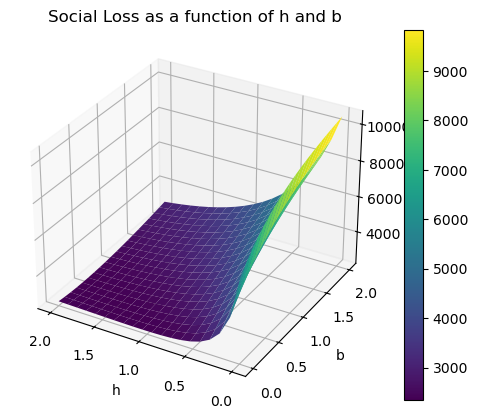

In [83]:
# 3d plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# meshgrid for h and b
h, b = np.meshgrid(possible_h, possible_b)

# Plot 3d surface
surf = ax.plot_surface(h, b, sl, cmap='viridis')

# Labels and titles
ax.set_xlabel('h')
ax.set_ylabel('b')
ax.set_zlabel('Social Loss')
ax.set_title('Social Loss as a function of h and b')
ax.invert_xaxis()

# Colorbar
fig.colorbar(surf)

# Show plot
plt.show()